[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_00a_boltzmann_h_theorem.ipynb)


# 00a. Boltzmann's H-theorem: from collisions to irreversible relaxation

_Master's course: Introduction to Synergetics · prerequisite before Module 01_

> **Guiding question:** How can reversible particle collisions produce an irreversible kinetic description, and why does this not forbid self-organization in an open system?

This notebook adapts the author's nonequilibrium statistical physics lectures, especially the microscopic phase-density method, the collision integral, and its entropy inequality in `sec_gaskinetic_ua.tex`, included by `stphysneq_ua.tex`. We retain this physical route and expand the intermediate steps needed for the present course. The full BBGKY derivation and transport coefficients are outside this introductory notebook.

Read after the [course introduction](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_00_course_map.ipynb), then continue to [Haken's laser](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_01_foundations.ipynb). The derivation uses dimensional momentum variables and explicit $k_B$; the computational illustrations use dimensionless variables. The notebooks run without the local TeX files.


## Learning outcomes

After this notebook you should be able to:

- distinguish microscopic phase density, an averaged one-particle distribution, and an $N$-particle distribution;
- identify the assumptions behind the Boltzmann collision integral;
- derive the collision-invariant identity and the sign of $dH/dt$;
- obtain the Maxwellian from the equality condition;
- separate local entropy production from entropy transport;
- explain the relation between molecular chaos, reversibility, and the limits of the theorem;
- interpret a collision-channel model and a BGK relaxation illustration without confusing either with a full Boltzmann solver.


## 1. From microscopic motion to a one-particle description

For one realization of $N$ classical particles define the microscopic phase density

$$\widehat n(\mathbf r,\mathbf p,t)=\sum_{i=1}^N
\delta^{(3)}(\mathbf r-\mathbf r_i(t))\delta^{(3)}(\mathbf p-\mathbf p_i(t)),
\qquad \int\widehat n\,d^3r\,d^3p=N.$$

This is a singular function recording exact particle locations, not yet a smooth probability density. Averaging over preparations gives the number distribution

$$f(\mathbf r,\mathbf p,t)=\langle\widehat n\rangle,\qquad
n(\mathbf r,t)=\int f\,d^3p,\qquad
\int f\,d^3r\,d^3p=N.$$

Thus $f\,d^3r\,d^3p$ is the mean number in a phase-space element. Where $n>0$, $f/n$ is a conditional momentum probability density. We use $f$ throughout to avoid mixing the probability and number normalizations used in different parts of the source notes. The mean momentum and thermal energy define $\mathbf u$ and $T$:

$$n m\mathbf u=\int\mathbf p f\,d^3p,\qquad
\frac32 n k_BT=\int\frac{|\mathbf p-m\mathbf u|^2}{2m}f\,d^3p.$$

An exact equation for the one-particle distribution involves a two-particle distribution; its equation involves a three-particle distribution. This is the BBGKY hierarchy. The decomposition into a product and a connected pair correlation makes the closure issue explicit:

$$f^{(2)}=f f+g^{(2)},$$

with consistent reduced-density conventions (finite-$N$ counting corrections are immaterial in the dilute kinetic limit). The essential question is which correlations can be neglected, and when—not merely how to average Newton's equations.


### Microscopic phase density obeys a continuity equation

To connect particle mechanics to continuum fields, first differentiate the delta functions in $\widehat n$. Write $\delta_a=\delta^{(3)}(\mathbf r-\mathbf r_a)\delta^{(3)}(\mathbf p-\mathbf p_a)$. Newton's equations give, in the distributional sense,

$$\partial_t\delta_a=-\mathbf v_a\cdot\nabla_{\mathbf r}\delta_a-\mathbf F_a\cdot\nabla_{\mathbf p}\delta_a.$$

Summing over particles and using $\mathbf v_a\delta_a=(\mathbf p/m)\delta_a$ yields the exact identity

$$\partial_t\widehat n+\nabla_{\mathbf r}\cdot(\mathbf v\widehat n)
+\nabla_{\mathbf p}\cdot\widehat{\mathbf J}_p=0,
\qquad \widehat{\mathbf J}_p=\sum_a\mathbf F_a\delta_a,
\qquad \mathbf v=\mathbf p/m.$$

This is conservation of particles in six-dimensional one-particle phase space. For a prescribed external force, its contribution to $\widehat{\mathbf J}_p$ is $\mathbf F_{\rm ext}\widehat n$. Interparticle forces depend on other particles, so their average cannot generally be replaced by a prescribed force times $f$. For smooth pair forces $\mathbf K(\mathbf r-\mathbf r')$, averaging produces

$$\langle\widehat{\mathbf J}_p\rangle=\mathbf F_{\rm ext}f+
\int\mathbf K(\mathbf r-\mathbf r')f^{(2)}(\mathbf r,\mathbf p;\mathbf r',\mathbf p',t)\,d^3r'\,d^3p'.$$

Here $f^{(2)}=\langle\sum_{a\ne b}\delta(\mathbf r-\mathbf r_a)\delta(\mathbf p-\mathbf p_a)\delta(\mathbf r'-\mathbf r_b)\delta(\mathbf p'-\mathbf p_b)\rangle$ counts ordered distinct pairs. This displays the first step of the BBGKY hierarchy. Hard-sphere interactions are handled through collision rules rather than a smooth pair force.

Integrating the phase continuity equation over momentum removes its momentum-divergence term (with vanishing boundary contribution). Thus particle conservation survives averaging **without a closure assumption**:

$$\partial_t n+\nabla\cdot(n\mathbf u)=0.$$

The dilute-gas approximation enters later: the effect of short binary encounters is represented by the Boltzmann collision integral. A second, distinct approximation—slow variation on the mean-free-path scale—is needed to close the continuum equations. The moment derivation below, after the Maxwellian section, separates these two steps.


### Following the source: averaging, reduced distributions, and the first hierarchy equation

Here we supply the steps between `fn–fschast` and `uravnf1–force` in the source. Let $W_N(x_1,\ldots,x_N,t)$ be the symmetric probability density of the full system, normalized to one, and $x_a=(\mathbf r_a,\mathbf p_a)$. Write $n=N/V_{\rm box}$ for the mean particle number density; $U_{ab}=U(|\mathbf r_a-\mathbf r_b|)$ denotes the pair potential. The source's reduced functions and our number distributions are related by

$$f_s^{\rm src}=\left(\frac{N}{n}\right)^s\int W_N\,dx_{s+1}\cdots dx_N,\qquad
f=n f_1^{\rm src},\qquad
f^{(2)}=n^2\left(1-\frac1N\right)f_2^{\rm src}\simeq n^2 f_2^{\rm src}.$$

Here the constant $n$ denotes the mean density. The local density is written explicitly as $n(\mathbf r,t)=\int f\,d^3p=n\int f_1^{\rm src}\,d^3p$ and need not equal $n$ in an inhomogeneous gas. This distinction prevents an extra density factor from entering the moment equations. For instance,

$$\langle\widehat n(x)\rangle=\sum_{a=1}^N\int\delta(x-x_a)W_N\,dx_1\cdots dx_N
=N\int W_N(x,x_2,\ldots)\,dx_2\cdots dx_N.$$

With $\mathbf K_{ab}=-\nabla_{\mathbf r_a}U_{ab}$, Liouville's equation is

$$\partial_tW_N+\sum_a\mathbf v_a\cdot\nabla_{\mathbf r_a}W_N
+\sum_a\left(\mathbf F_{0a}+\sum_{b\ne a}\mathbf K_{ab}\right)\cdot\nabla_{\mathbf p_a}W_N=0.$$

Integrate over $x_2,\ldots,x_N$ and multiply by $N$. All divergences in integrated variables vanish under periodic/decaying boundary conditions. The $N-1$ identical force terms acting on particle 1 combine into the pair density:

$$\left(\partial_t+\mathbf v_1\cdot\nabla_{\mathbf r_1}+\mathbf F_{01}\cdot\nabla_{\mathbf p_1}\right)f(x_1)
=-\int\mathbf K_{12}\cdot\nabla_{\mathbf p_1}f^{(2)}(x_1,x_2)\,dx_2.$$

In the source normalization the coefficient on the right is $n(1-1/N)$; it becomes $n$ in the large-system approximation used there. With $g^{(2)}=f^{(2)}-f(x_1)f(x_2)$, the product contribution is

$$-\int\mathbf K_{12}\cdot\nabla_{\mathbf p_1}[f(x_1)f(x_2)]\,dx_2
=-\mathbf F_{\rm mf}(\mathbf r_1,t)\cdot\nabla_{\mathbf p_1}f(x_1),\qquad
\mathbf F_{\rm mf}=\int\mathbf K_{12}f(x_2)\,dx_2.$$

Move it to the left. The resulting form of `uravnf11` is

$$[\partial_t+\mathbf v\cdot\nabla_{\mathbf r}+(\mathbf F_0+\mathbf F_{\rm mf})\cdot\nabla_{\mathbf p}]f
=-\int\mathbf K_{12}\cdot\nabla_{\mathbf p_1}g^{(2)}\,dx_2.$$

The right side represents correlations, but is not yet the local Boltzmann collision operator. The exact pair equation exposes the next unknown:

$$[\partial_t+\mathcal L_{12}]f^{(2)}
=-\int(\mathbf K_{13}\cdot\nabla_{\mathbf p_1}+\mathbf K_{23}\cdot\nabla_{\mathbf p_2})f^{(3)}\,dx_3,$$
$$\mathcal L_{12}=\sum_{a=1}^{2}[\mathbf v_a\cdot\nabla_{\mathbf r_a}+\mathbf F_{0a}\cdot\nabla_{\mathbf p_a}]
+\mathbf K_{12}\cdot(\nabla_{\mathbf p_1}-\nabla_{\mathbf p_2}).$$

The full structure of the chain is now visible. For $1\le s<N$, define

$$f^{(s)}=\frac{N!}{(N-s)!}\int W_N\,dx_{s+1}\cdots dx_N.$$
$$\left[\partial_t+\sum_{a=1}^{s}(\mathbf v_a\cdot\nabla_{\mathbf r_a}+\mathbf F_{0a}\cdot\nabla_{\mathbf p_a})
+\sum_{a<b\le s}\mathbf K_{ab}\cdot(\nabla_{\mathbf p_a}-\nabla_{\mathbf p_b})\right]f^{(s)}
=-\sum_{a=1}^{s}\int\mathbf K_{a,s+1}\cdot\nabla_{\mathbf p_a}f^{(s+1)}\,dx_{s+1}.$$

On the left are free motion, external forcing, and interactions within the selected group of $s$ particles. On the right are interactions with a particle outside that group, averaged over its state; this introduces $f^{(s+1)}$. The chain ends at $s=N$, where there is no outside particle. In the source's reduced-distribution normalization the right side carries $n(1-s/N)$, approximately $n$ at fixed $s\ll N$. The need for a closure is thus a physical consequence of interactions, not a failure of averaging.

The source expands $f^{(3)}$ into a product, three pair-correlation terms, and a connected triple correlation. Neglecting the latter is one step in the dilute binary approximation; neglect of overlapping encounters and the condition on incoming correlations are additional assumptions. For short-range dilute-gas kinetics below we retain the prescribed external force and describe encounters by $C[f]$. We do not add the same interactions again as a mean field; a retained mean field would require a consistent interaction-energy balance.


### Correlation functions: the structure of the chain and the binary closure

This is the step `g2–g3` → `urf2_1` → `i1,i123` → `urf22` in the original lectures. Here “chain” means the **BBGKY hierarchy**; the BGK relaxation model introduced later is a different approximation. To avoid confusing a one-particle value with a two-particle function, write $a_i=f(x_i,t)$, $F_{ij}=f^{(2)}(x_i,x_j,t)$, and $F_{123}=f^{(3)}(x_1,x_2,x_3,t)$. Define connected correlations by

$$F_{12}=a_1a_2+G_{12},$$
$$F_{123}=a_1a_2a_3+G_{12}a_3+G_{13}a_2+G_{23}a_1+G_{123}
=F_{12}a_3+G_{13}a_2+G_{23}a_1+G_{123}.$$

These are definitions, not approximations. $a_1a_2a_3$ describes independent particles; $G_{12}a_3$ describes a correlated pair and an independent third particle, with two other pair choices. $G_{123}$ is the part of the three-particle distribution not represented by any of these products. It is not the whole three-particle function. Neglecting $G_{123}$ therefore does **not** mean setting $F_{123}$ to zero. For fixed finite $N$, the chosen number-density convention also places counting corrections in the connected functions; these are negligible in the dilute large-system treatment here.

The first hierarchy equation, after extracting the mean field, is

$$\mathcal D_i a_i=I_i,\qquad
\mathcal D_i=\partial_t+\mathbf v_i\cdot\nabla_{\mathbf r_i}
+(\mathbf F_{0i}+\mathbf F_{{\rm mf},i})\cdot\nabla_{\mathbf p_i},\qquad
I_i=-\int\mathbf K_{i3}\cdot\nabla_{\mathbf p_i}G_{i3}\,dx_3.$$

Now insert the full expansion of $F_{123}$ in the pair equation. Define

$$\mathcal D_{12}=\partial_t+\sum_{i=1}^{2}[\mathbf v_i\cdot\nabla_{\mathbf r_i}
+(\mathbf F_{0i}+\mathbf F_{{\rm mf},i})\cdot\nabla_{\mathbf p_i}],\qquad
\mathcal L_{\rm int}=\mathbf K_{12}\cdot(\nabla_{\mathbf p_1}-\nabla_{\mathbf p_2}).$$

There is **one** time derivative in $\mathcal D_{12}$. The terms are obtained as follows:

| Part of $F_{123}$ | Contribution to the pair equation | Physical role |
|---|---|---|
| $F_{12}a_3$ | $-\mathbf F_{{\rm mf},1}\cdot\nabla_{\mathbf p_1}F_{12}-\mathbf F_{{\rm mf},2}\cdot\nabla_{\mathbf p_2}F_{12}$ | Average force of particle 3; move to the streaming side |
| $G_{13}a_2$ with $\mathbf K_{13}\cdot\nabla_{\mathbf p_1}$ | $a_2 I_1$ | Change of particle 1's distribution through its correlations with others |
| $G_{23}a_1$ with $\mathbf K_{23}\cdot\nabla_{\mathbf p_2}$ | $a_1 I_2$ | The corresponding change for particle 2 |
| Cross action on $G_{13}a_2$ and $G_{23}a_1$ | $X_{12}$ below | A third particle couples the two members of the pair |
| $G_{123}$ | $T_{12}$ below | Connected three-particle contribution |

For example, the direct term is $-\int\mathbf K_{13}\cdot\nabla_{\mathbf p_1}(G_{13}a_2)\,dx_3=a_2I_1$, since $a_2$ is independent of $\mathbf p_1$. The crossed terms are

$$X_{12}=-\nabla_{\mathbf p_1}a_1\cdot\int\mathbf K_{13}G_{23}\,dx_3
-\nabla_{\mathbf p_2}a_2\cdot\int\mathbf K_{23}G_{13}\,dx_3,$$
$$T_{12}=-\int(\mathbf K_{13}\cdot\nabla_{\mathbf p_1}+\mathbf K_{23}\cdot\nabla_{\mathbf p_2})G_{123}\,dx_3.$$

Consequently the reorganized pair equation is

$$\boxed{(\mathcal D_{12}+\mathcal L_{\rm int})F_{12}
=a_2I_1+a_1I_2+X_{12}+T_{12}.}$$

The product rule and the first hierarchy equation give $\mathcal D_{12}(a_1a_2)=a_2I_1+a_1I_2$. Subtract this identity, keeping the direct interaction term, to obtain an equation showing how correlations are created:

$$\boxed{(\mathcal D_{12}+\mathcal L_{\rm int})G_{12}
=-\mathcal L_{\rm int}(a_1a_2)+X_{12}+T_{12}.}$$

Even if a pair is initially uncorrelated, its direct interaction generates $G_{12}$. Setting all pair correlations to zero would erase the collision mechanism we are trying to derive.

For short-range forces in a dilute gas, the source neglects connected triple correlations ($T_{12}$) and overlapping encounters represented by $X_{12}$. The latter omission is an additional binary-collision assumption, not an algebraic consequence of $G_{123}=0$; it also requires control of incoming correlations and recollisions. Then

$$ (\mathcal D_{12}+\mathcal L_{\rm int})F_{12}
\simeq\mathcal D_{12}(a_1a_2).$$

Together with $\mathcal D_1a_1=I_1[G_{12}]$, this is the source's approximate closed pair system. The next step freezes the slow one-particle variation during a short encounter. Its right side is then higher order on the encounter timescale, yielding a two-body characteristic equation for $F_{12}$. **The collision integral is obtained by solving that pair problem with an incoming boundary condition and substituting the result into the first hierarchy equation.**


## 2. Dilute gas, molecular chaos, and binary collisions

Consider a classical dilute gas of identical particles with short-range interactions. If $r_0$ is the interaction range, $n r_0^3\ll1$ suppresses simultaneous many-particle encounters. The collision duration is short compared with the mean free time, and the distribution varies little over the collision region. We retain elastic binary collisions and ignore quantum statistical effects.

The **molecular-chaos assumption** factorizes the distribution of particles approaching a collision:

$$f^{(2)}_{\rm in}(\mathbf r,\mathbf p_1,\mathbf p_2,t)
\simeq f(\mathbf r,\mathbf p_1,t)f(\mathbf r,\mathbf p_2,t).$$

It is an assumption about incoming pairs on the kinetic scale, not a claim that collisions create no correlations. Outgoing particles are generally correlated. This is the physical closure corresponding to the treatment of past incoming momenta in the source notes.

For equal masses, write $\mathbf q=\mathbf p_1-\mathbf p_2$ and let $\mathbf n$ be the collision normal. A convenient hard-sphere collision rule is

$$\mathbf p'_1=\mathbf p_1-(\mathbf q\cdot\mathbf n)\mathbf n,\qquad
\mathbf p'_2=\mathbf p_2+(\mathbf q\cdot\mathbf n)\mathbf n.$$

It conserves pair momentum and kinetic energy:

$$\mathbf p_1+\mathbf p_2=\mathbf p'_1+\mathbf p'_2,\qquad
\frac{p_1^2+p_2^2}{2m}=\frac{p_1'^2+p_2'^2}{2m}.$$

The map is reversible. The loss of time-reversal symmetry in the closed kinetic description therefore cannot be attributed to inelasticity of these collisions.


### From the pair characteristics to gain minus loss

This expands `urf220–collint_boltz1`. Let $r_0$ be the interaction range, $v_T$ a typical relative speed, and $\epsilon=nr_0^3\ll1$. Estimates give

$$\tau_0\sim r_0/v_T,\qquad \ell\sim1/(nr_0^2),\qquad
\tau_{\rm coll}\sim\ell/v_T,\qquad \tau_0/\tau_{\rm coll}\sim\epsilon.$$

The duration of one encounter is much shorter than the mean time between encounters. Over an encounter the slowly varying one-particle fields can be frozen; triple encounters are neglected. This separation is different from the later continuum condition $\ell/L\ll1$.

On the binary characteristics, to leading order,

$$[\partial_t+\mathcal L_{12}]f^{(2)}\simeq0,\qquad
\frac{d}{ds}f^{(2)}(x_1(s),x_2(s),t+s)\simeq0.$$

Impose factorization on the incoming branch, before the encounter. If $\mathbf P_1,\mathbf P_2$ are the asymptotic incoming momenta of the trajectory passing through $(x_1,x_2)$, then locally

$$f^{(2)}(x_1,x_2,t)\simeq f(\mathbf r_1,\mathbf P_1,t)f(\mathbf r_1,\mathbf P_2,t),$$
$$\mathbf P_1+\mathbf P_2=\mathbf p_1+\mathbf p_2,\qquad
\frac{P_1^2+P_2^2}{2m}=\frac{p_1^2+p_2^2}{2m}+U(r_{12}).$$

The asymptotic momenta depend on the present relative position and both momenta. Thus this is not factorization in the present momenta during a collision; collision correlations remain.

For clarity, take $\mathbf r=\mathbf r_1-\mathbf r_2$ and $\mathbf g=\mathbf v_1-\mathbf v_2$. Freezing slow variables gives the pair equation

$$\mathbf g\cdot\nabla_{\mathbf r}f^{(2)}
+\mathbf K_{12}\cdot(\nabla_{\mathbf p_1}-\nabla_{\mathbf p_2})f^{(2)}\simeq0.$$

In the first hierarchy equation, the force contribution becomes $\int\mathbf g\cdot\nabla_{\mathbf r}f^{(2)}\,d^3r\,d^3p_2$: the extra $\mathbf p_2$ derivative integrates to zero because $\mathbf K_{12}$ is momentum-independent. Subtract the uncorrelated constant background if needed before the spatial integration. Choose $z$ along $\mathbf g$ and transverse impact coordinates $(b,\varphi)$. Then

$$\mathbf g\cdot\nabla_{\mathbf r}=|\mathbf g|\partial_z,\qquad
d^3r=b\,db\,d\varphi\,dz,$$
$$\int_{-\infty}^{\infty}|\mathbf g|\partial_z f^{(2)}\,dz
=|\mathbf g|[f^{(2)}(+\infty)-f^{(2)}(-\infty)].$$

The incoming end gives $f(\mathbf p_1)f(\mathbf p_2)$. At the outgoing end the distribution is expressed using the incoming momenta of the inverse scattering event, denoted $\mathbf p'_1,\mathbf p'_2$. Reversibility supplies the same collision measure, so

$$C[f](\mathbf p_1)=\int d^3p_2\int b\,db\,d\varphi\,|\mathbf g|
[f(\mathbf p'_1)f(\mathbf p'_2)-f(\mathbf p_1)f(\mathbf p_2)].$$

Finally $b\,db\,d\varphi=(d\sigma/d\Omega)d\Omega$ (summing scattering branches when necessary) gives $B=|\mathbf g|\,d\sigma/d\Omega$ in the next section. After evaluating the endpoints there is **no remaining $dz$ integral**. The repeated $dz$ in the source's final formula is a typographical carry-over. The crucial statistical input was the incoming boundary condition, not the reversible scattering map.


## 3. The Boltzmann equation as gain minus loss

With $\mathbf v=\mathbf p/m$ and an external force $\mathbf F(\mathbf r,t)$ independent of momentum,

$$\left(\partial_t+\mathbf v\cdot\nabla_{\mathbf r}
+\mathbf F\cdot\nabla_{\mathbf p}\right)f=C[f].$$

At fixed $(\mathbf r,t)$ abbreviate $f_i=f(\mathbf p_i)$ and $f'_i=f(\mathbf p'_i)$. Then

$$C[f](\mathbf p_1)=\int d^3p_2\,d\Omega\,
B(\mathbf p_1,\mathbf p_2,\Omega)\big(f'_1f'_2-f_1f_2\big),\qquad B\ge0.$$

The loss term counts pairs removed from the state with momentum $\mathbf p_1$; the gain term counts reverse collisions that populate it. The same collision map can label either direction because of microscopic reversibility. The kernel contains relative speed and differential scattering cross-section, $B=|\mathbf v_1-\mathbf v_2|\,d\sigma/d\Omega$ in the usual scattering-angle convention. For a collision-normal parametrization its angular factor changes; positive geometric prefactors are absorbed into $B$ consistently.

We need two symmetries: exchange of identical particles, and invariance of the collision measure under exchanging incoming and outgoing states. Define

$$d\Gamma=d^3p_1\,d^3p_2\,d\Omega\,B,\qquad X=f_1f_2,\qquad Y=f'_1f'_2.$$

The measure is nonnegative. Its symmetry, rather than the particular hard-sphere prefactor, drives the proof. The collision term is nonlinear because encounters involve pairs: their rate is proportional to a product of distributions.


## 4. Symmetrization and collision invariants

For a test function $\varphi(\mathbf p)$ consider the collision-induced rate of its mean. Exchanging particles $1\leftrightarrow2$ gives the same integral, so averaging yields

$$I_\varphi=\int \varphi_1 C[f]_1\,d^3p_1
=\frac12\int d\Gamma\,(\varphi_1+\varphi_2)(Y-X).$$

Now interchange pre- and post-collision variables. The measure is unchanged, while $Y-X$ reverses sign:

$$I_\varphi=-\frac12\int d\Gamma\,(\varphi'_1+\varphi'_2)(Y-X).$$

Averaging these two forms produces the key identity:

$$\boxed{I_\varphi=\frac14\int d\Gamma\,
(\varphi_1+\varphi_2-\varphi'_1-\varphi'_2)(Y-X).}$$

The factor $1/4$ comes from two symmetrizations. If the pair sum of $\varphi$ is conserved in every allowed collision, the bracket vanishes. Consequently,

$$\int C[f]\,d^3p=0,\qquad
\int \mathbf p\,C[f]\,d^3p=\mathbf0,\qquad
\int\frac{p^2}{2m}C[f]\,d^3p=0.$$

These are conservation of particle number, momentum, and kinetic energy by collisions. Under the usual regularity and nondegeneracy assumptions for elastic scattering in three dimensions, the general collision invariant is

$$\varphi(\mathbf p)=a+\mathbf b\cdot\mathbf p+c\,p^2.$$

The linear term is essential. A shifted-square expression is useful when $c\ne0$, but it does not by itself represent every pure momentum invariant.


## 5. The H-theorem, step by step

First take a spatially homogeneous gas with no external force, so $\partial_t f=C[f]$. Define an H-functional per unit volume,

$$h[f]=\int f\ln\frac{f}{f_{\rm ref}}\,d^3p,$$

where $f_{\rm ref}>0$ is a fixed constant with the same units as $f$. This makes the logarithm dimensionless; changing this reference only adds a multiple of the conserved number density. The kinetic entropy density is $s=-k_Bh$ up to such a constant.

Assume the integrals and differentiations exist and first take $f>0$. Since $\int C[f]d^3p=0$,

$$\frac{dh}{dt}=\int\left(1+\ln\frac{f}{f_{\rm ref}}\right)C[f]d^3p
=\int\ln\frac{f}{f_{\rm ref}}\,C[f]d^3p.$$

Use the weak form with $\varphi=\ln(f/f_{\rm ref})$ at this instant. Its pair difference is $\ln(X/Y)$, so

$$\frac{dh}{dt}=\frac14\int d\Gamma\,(Y-X)\ln\frac XY
=-\frac14\int d\Gamma\,(X-Y)(\ln X-\ln Y).$$

The logarithm is increasing. If $X>Y$, both differences in the last product are positive; if $X<Y$, both are negative. Hence

$$\boxed{(X-Y)\ln(X/Y)\ge0,\qquad
\frac{dh}{dt}\le0,\qquad
\sigma=\frac{ds}{dt}=\frac{k_B}{4}\int d\Gamma\,(X-Y)\ln\frac XY\ge0.}$$

This is the classical Boltzmann H-theorem. Zeros are treated by suitable limits with $f\ln f\to0$ as $f\downarrow0$, subject to finite entropy production. The sign follows pointwise for each collision channel; it is not an empirical fit to an entropy curve.

**Sign check.** Taking $X=4$, $Y=1$ gives $(X-Y)\ln(X/Y)=3\ln4>0$. The expression with $Y-X$ has the opposite sign. Keeping the convention “H decreases, entropy increases” visible prevents a common error.


## 6. Equality and the Maxwell distribution

Zero entropy production requires $X=Y$ for almost every allowed collision with nonzero kernel. Thus

$$f_1f_2=f'_1f'_2
\quad\Longleftrightarrow\quad
\ln f_1+\ln f_2=\ln f'_1+\ln f'_2.$$

The logarithm is a collision invariant. With the assumptions above,

$$\ln f=a+\mathbf b\cdot\mathbf p+c p^2,\qquad c<0.$$

Normalizability requires the negative quadratic term. Completing the square and identifying the conserved moments gives

$$\boxed{f_M(\mathbf r,\mathbf p,t)=
\frac{n(\mathbf r,t)}{[2\pi m k_BT(\mathbf r,t)]^{3/2}}
\exp\left[-\frac{|\mathbf p-m\mathbf u(\mathbf r,t)|^2}{2m k_BT(\mathbf r,t)}\right].}$$

Check all three moments: $\int f_Md^3p=n$, $\int\mathbf p f_Md^3p=nm\mathbf u$, and the random kinetic energy is $3nk_BT/2$. In particular, the denominator of the exponent is $2mk_BT$ when using momentum, whereas it is $2k_BT/m$ when using velocity.

A **local Maxwellian** satisfies $C[f_M]=0$ pointwise, but spatially varying $n,\mathbf u,T$ generally give nonzero streaming. It need not solve the full Boltzmann equation or represent global equilibrium. In a homogeneous force-free gas the moments fix a stationary Maxwellian; with an external potential, equilibrium can instead be spatially nonuniform.

For any homogeneous $f$ with the same number, momentum, and energy as $f_M$, $\ln(f_M/f_{\rm ref})$ is an invariant combination, so

$$h[f]-h[f_M]=\int f\ln\frac{f}{f_M}\,d^3p
=nD_{\rm KL}(f/n\,\|\,f_M/n)\ge0.$$

Hence the Maxwellian minimizes $h$ under these constraints. The H-theorem gives monotonicity and characterizes zero production; by itself it does not establish a universal convergence rate or a full convergence theorem for every initial condition.


### From gas kinetics to continuum mechanics: the moment method

We now expand the transport-equation part of `sec_gaskinetic_ua.tex`. Consider a three-dimensional dilute monatomic gas with elastic collisions, particle mass $m$, and momentum-independent external force $\mathbf F$ per particle. Use the number distribution $f$ already defined, with no additional factor of $n$ in its moments. Assume sufficiently rapid decay as $|\mathbf p|\to\infty$ and finite required moments. Repeated Cartesian indices are summed, $\partial_j=\partial/\partial r_j$, and $D_t=\partial_t+\mathbf u\cdot\nabla$.

Multiply the Boltzmann equation by any smooth $\psi(\mathbf r,\mathbf p,t)$ and integrate. Product differentiation and integration by parts give

$$\partial_t\int\psi f\,d^3p+\partial_j\int v_j\psi f\,d^3p
=\int f(\partial_t\psi+v_j\partial_j\psi+F_j\partial_{p_j}\psi)\,d^3p
+\int\psi C[f]\,d^3p.$$

For example, $\int\psi F_j\partial_{p_j}f\,d^3p=-\int f F_j\partial_{p_j}\psi\,d^3p$. This explains the force sign. For $\psi=m,p_i,p^2/(2m)$, the collision term vanishes by the collision invariants proved above.

| Weight $\psi$ | Density $\int\psi f\,d^3p$ | Flux in direction $j$ | External source |
|---|---|---|---|
| $m$ | $\rho=mn$ | $\rho u_j$ | $0$ |
| $p_i$ | $\rho u_i$ | $\rho u_i u_j+\Pi_{ij}$ | $nF_i$ |
| $p^2/(2m)$ | $\mathcal E$ | $\mathcal E u_j+\Pi_{ij}u_i+q_j$ | $n\mathbf F\cdot\mathbf u$ |

The table is the bridge from a distribution in phase space to three-dimensional continuum fields. The balances are exact consequences of the **Boltzmann model**; their constitutive closure is still to be supplied.


### Mass and momentum: how pressure and viscous stress appear

Separate mean motion from thermal motion: $\mathbf v=\mathbf u+\mathbf c$, where $\mathbf c$ is the peculiar velocity. By definition $\int\mathbf c f\,d^3p=0$. Therefore

$$\int m v_i v_j f\,d^3p=\rho u_i u_j+\Pi_{ij},\qquad
\Pi_{ij}=m\int c_i c_j f\,d^3p.$$

The cross terms vanish, but the quadratic thermal term does not. Random molecular motion thus transports momentum even when the mean velocity is zero. Decompose this momentum flux as

$$\Pi_{ij}=P\delta_{ij}+\pi_{ij},\quad
P=\tfrac13\Pi_{ii}=nk_BT,\quad \pi_{ii}=0.$$

We denote scalar pressure by $P$ to distinguish it from particle momentum $\mathbf p$. For this monatomic kinetic model, the second moment defines $T$ even away from local equilibrium. The balances become

$$\boxed{\partial_t\rho+\nabla\cdot(\rho\mathbf u)=0,}$$
$$\partial_t(\rho u_i)+\partial_j(\rho u_i u_j)=-\partial_i P-\partial_j\pi_{ij}+nF_i.$$

Expanding the left side of the second equation gives $\rho D_tu_i+u_i[\partial_t\rho+\partial_j(\rho u_j)]$. The bracket vanishes by continuity, leaving

$$\boxed{\rho D_tu_i=-\partial_iP-\partial_j\pi_{ij}+nF_i.}$$

**Sign convention.** $\Pi$ is the thermal momentum-flux tensor. The Cauchy stress used in continuum mechanics is $\sigma_{ij}=-P\delta_{ij}+\tau_{ij}$, where $\tau_{ij}=-\pi_{ij}$. Thus the same equation reads $\rho D_t\mathbf u=\nabla\cdot\boldsymbol\sigma+n\mathbf F$. The minus sign is a convention, not a negative viscosity.


### Energy: separate bulk motion, internal energy, and heat flux

Define internal energy per unit mass $e$, total kinetic energy per unit volume $\mathcal E$, and heat flux $\mathbf q$:

$$\rho e=\int\tfrac m2c^2f\,d^3p=\tfrac32 nk_BT,\quad
\mathcal E=\tfrac12\rho u^2+\rho e,\quad
q_j=\int\tfrac m2c^2c_jf\,d^3p.$$

Here $\mathcal E$ excludes external potential energy. Expand $v^2v_j=(u^2+2u_ic_i+c^2)(u_j+c_j)$. Terms linear in $\mathbf c$ vanish on integration; the others give

$$\int\tfrac m2v^2v_j f\,d^3p
=\mathcal E u_j+\Pi_{ij}u_i+q_j.$$

The terms are convective energy transport, mechanical work, and heat transport. In particular, $q_j$ is already an energy flux; it must not be multiplied by another velocity. The energy moment gives

$$\boxed{\partial_t\mathcal E+\nabla\cdot[(\mathcal E+P)\mathbf u
+\boldsymbol\pi\cdot\mathbf u+\mathbf q]=n\mathbf F\cdot\mathbf u.}$$

To obtain the thermal equation, dot the momentum balance with $\mathbf u$ and use continuity:

$$\partial_t(\tfrac12\rho u^2)+\partial_j(\tfrac12\rho u^2u_j)
=-\partial_j(u_i\Pi_{ij})+\Pi_{ij}\partial_ju_i+nF_iu_i.$$

Subtract this from total energy balance. The external work cancels because it acts on the mean motion, and

$$\rho D_te=-P\nabla\cdot\mathbf u-\pi_{ij}\partial_ju_i-\nabla\cdot\mathbf q.$$

For the monatomic gas $e=c_vT$, $c_v=3k_B/(2m)$, so

$$\boxed{\rho c_vD_tT=-P\nabla\cdot\mathbf u
+\tau_{ij}\partial_ju_i-\nabla\cdot\mathbf q.}$$

Compression heats the gas, viscous work converts bulk kinetic energy into internal energy, and heat flux redistributes energy. Conservation of collision energy does **not** eliminate viscosity or heat conduction: collisions change the distribution and thereby determine the fluxes.


### The missing second-moment calculation: `natayg0` → `natayg` → `pressure`

Define $Q_{ijk}=m\int c_ic_jc_kf\,d^3p$ (the source's $S_{ijk}$), so $Q_{iik}=2q_k$, and $\mathcal C_{ij}=m\int c_ic_jC[f]\,d^3p$. Multiply the kinetic equation by $mv_iv_j$, **not by $mv_iv_jf$**. Integration by parts gives

$$\int mv_iv_jF_k\partial_{p_k}f\,d^3p=-n(F_iu_j+F_ju_i),$$
$$\partial_t(\rho u_iu_j+\Pi_{ij})+
\partial_k[\rho u_iu_ju_k+u_k\Pi_{ij}+u_j\Pi_{ik}+u_i\Pi_{jk}+Q_{ijk}]
=n(F_iu_j+F_ju_i)+\mathcal C_{ij}.$$

The flux follows by expanding all eight terms of $(u_i+c_i)(u_j+c_j)(u_k+c_k)$: the three terms linear in $\mathbf c$ vanish, the three quadratic terms produce $u_i\Pi_{jk}$ and its permutations, and the cubic term is $Q_{ijk}$. Collision invariance allows $v_iv_j$ to be replaced by $c_ic_j$ on the right.

The bulk part can be reduced without an unspecified symmetrization:

$$\partial_t(\rho u_iu_j)+\partial_k(\rho u_iu_ju_k)
=\rho(u_jD_tu_i+u_iD_tu_j)
=-u_j\partial_k\Pi_{ik}-u_i\partial_k\Pi_{jk}+n(u_jF_i+u_iF_j).$$

Now expand $\partial_k(u_j\Pi_{ik})=u_j\partial_k\Pi_{ik}+\Pi_{ik}\partial_ku_j$, and similarly for $i\leftrightarrow j$. The two pressure-divergence terms cancel the bulk terms; the external forces cancel as well. What remains is

$$\boxed{D_t\Pi_{ij}+\Pi_{ij}\partial_ku_k+\Pi_{ik}\partial_ku_j
+\Pi_{jk}\partial_ku_i+\partial_kQ_{ijk}=\mathcal C_{ij}.}$$

Take the trace. Elastic collision invariance gives $\mathcal C_{ii}=0$ because $mc^2=mv^2-2m\mathbf u\cdot\mathbf v+mu^2$ is a combination of invariants at each point. Since $\Pi_{ii}=3P$,

$$3D_tP+3P\nabla\cdot\mathbf u+2(P\delta_{ik}+\pi_{ik})\partial_ku_i+2\partial_kq_k=0,$$
$$\boxed{D_tP+\frac53P\nabla\cdot\mathbf u
+\frac23[\pi_{ik}\partial_ku_i+\nabla\cdot\mathbf q]=0.}$$

This reproduces `pressure` and agrees with the thermal-energy equation because $\rho e=3P/2$. The trace equation removes the isotropic part; the remaining traceless equation determines viscous stress.


### Small gradients: deriving `viscnatyag` from the stress equation

Define the traceless strain-rate tensor

$$S_{ij}=\tfrac12(\partial_iu_j+\partial_ju_i)-\tfrac13\delta_{ij}\nabla\cdot\mathbf u.$$

Write $\delta=\ell/L\ll1$, separate from the dilute-gas parameter $nr_0^3$. In collision-time units, a hydrodynamic derivative is $O(\delta)$, while $\pi/P$ and $Q/(Pv_T)$ are $O(\delta)$. Thus derivatives of these nonequilibrium moments are $O(\delta^2)$. For the first-order constitutive law, set $\Pi=P\mathbb I$ and $Q=0$ **only on the streaming side** of the preceding stress equation, retaining the collision relaxation of $\pi$ on the right:

$$\mathcal C_{ij}^{(1)}=[D_tP+P\nabla\cdot\mathbf u]\delta_{ij}
+P(\partial_iu_j+\partial_ju_i).$$

The trace equation at this order is $D_tP=-(5/3)P\nabla\cdot\mathbf u$. Substitution yields

$$\mathcal C_{ij}^{(1)}=P\left(\partial_iu_j+\partial_ju_i-\frac23\delta_{ij}\nabla\cdot\mathbf u\right)=2PS_{ij}.$$

The source's next step (`pi1`) introduces a relaxation description of the traceless collision moment. State this assumption explicitly, with a positive stress-relaxation rate $\nu_\pi$:

$$\mathcal C_{ij}^{(1)}=-\nu_\pi\pi_{ij},\qquad
\pi_{ij}=-\frac{2P}{\nu_\pi}S_{ij},\qquad \eta=\frac{P}{\nu_\pi}>0.$$

Hence $\pi_{ij}=-\eta(\partial_iu_j+\partial_ju_i-\tfrac23\delta_{ij}\nabla\cdot\mathbf u)$, exactly the source's `viscnatyag`. It follows from the moment equation **and a collision closure**, not from symmetry alone. A scalar rate is an illustrative closure; for a general Boltzmann kernel one determines the stress response by solving the linearized collision equation. At this order the isotropic bracket has no first-gradient contribution; its dissipative corrections are second order, as the explicit trace equation shows.


### The heat-flux moment: filling the steps `heat0–heat03`

First take the source's raw moment with weight $mv^2v_i/2$. Define $J_i=\mathcal E u_i+\Pi_{ij}u_j+q_i$ and $M_{ik}=\int(m/2)v^2v_iv_kf\,d^3p$. Differentiating the weight with respect to momentum gives the exact equation

$$\partial_tJ_i+\partial_kM_{ik}
=\frac{\mathcal E}{m}F_i+\frac{F_k}{m}(\rho u_iu_k+\Pi_{ik})
+\mathcal C_i^q+u_j\mathcal C_{ij},\qquad
\mathcal C_i^q=\int\tfrac m2 c^2c_iC[f]\,d^3p.$$

The collision identity follows by expanding $v^2v_i$ and discarding its conserved zeroth, first, and energy moments. This explains the stress term proportional to $\pi_{ij}u_j$ in `heat2`.

To display the subtraction of the bulk-motion contributions without hiding any derivatives, use the equivalent central weight $\psi_i=mc^2c_i/2$ in the general moment identity. Define

$$R_{ik}=\int\tfrac m2c^2c_ic_kf\,d^3p,\qquad
A_j=D_tu_j-F_j/m.$$

Here $\mathscr D=\partial_t+\mathbf v\cdot\nabla_{\mathbf r}+\mathbf F\cdot\nabla_{\mathbf p}$. The weight depends on $\mathbf r,t$ through $\mathbf u$. Its streaming derivative is

$$\mathscr D c_j=-A_j-c_k\partial_ku_j,\qquad
\mathscr D\psi_i=-\frac m2(c^2\delta_{ij}+2c_ic_j)(A_j+c_k\partial_ku_j).$$

Integrate each term separately. The coefficient of $A_j$ is $3P\delta_{ij}/2+\Pi_{ij}$; the coefficient of $\partial_ku_j$ is $q_k\delta_{ij}+Q_{ijk}$. Also $\int v_k\psi_i f=u_kq_i+R_{ik}$. Thus the exact central equation is

$$D_tq_i+q_i\partial_ku_k+\partial_kR_{ik}
=-\left(\frac32P\delta_{ij}+\Pi_{ij}\right)A_j
-(q_k\delta_{ij}+Q_{ijk})\partial_ku_j+\mathcal C_i^q.$$

This implements the same removal of mean-flow energy as `denskin02–heat03`. Now retain only first-gradient streaming terms. Set $\Pi_{ij}=P\delta_{ij}$, use Euler's equation $A_i=-\partial_iP/\rho$, and use the Maxwellian fourth moment, with $\theta=k_BT/m=P/\rho$:

$$R_{ik}^{(0)}=\frac m2 n\langle c^2c_ic_k\rangle_M
=\frac52P\theta\delta_{ik}.$$

Since $q,Q$ are first order, their derivatives and products with velocity gradients contribute only at second order. The heat equation therefore reduces to

$$\frac52\partial_i(P\theta)=\frac52\frac P\rho\partial_iP+\mathcal C_i^{q(1)},$$
$$\mathcal C_i^{q(1)}=\frac52[\theta\partial_iP+P\partial_i\theta-\theta\partial_iP]
=\frac52\frac{k_B}{m}P\partial_iT.$$

The pressure-gradient terms cancel explicitly. Introduce positive heat-flux relaxation $\mathcal C_i^{q(1)}=-\nu_q q_i$:

$$\boxed{q_i=-\lambda\partial_iT,\qquad \lambda=\frac52\frac{k_B}{m}\frac P{\nu_q}>0.}$$

This is Fourier's law. Keeping $\nu_q$ distinct from $\nu_\pi$ avoids identifying heat conduction with stress relaxation; BGK below makes the particular choice $\nu_q=\nu_\pi=1/\tau_R$. In the source's `heat2`, the heat-flux term must be a negative relaxation term with the correct dimensions. With $\lambda$ defined as thermal conductivity, it is $-\tfrac52(k_B/m)(P/\lambda)q_i$, not $+(P/\lambda)q_i$. Following the source's moment route therefore requires this correction. Its final reference to Fick's law for heat should read Fourier's law.


### Closing the balances: Euler and Navier–Stokes–Fourier equations

The five balance equations evolve $n$, the three components of $\mathbf u$, and $T$, but contain additional moments $\pi_{ij}$ and $q_i$. Equations for these moments introduce still higher ones. **Taking moments is not yet a closure.**

For fields varying slowly over a mean free path $\ell$ and collision time $\tau_{\rm coll}$, define $\mathrm{Kn}=\ell/L\ll1$ and require slow macroscopic time variation as well. Away from kinetic boundary layers and sharp gradients, seek $f=f_M+f^{(1)}+\cdots$, with $f^{(1)}$ first order in Knudsen number in the moment expansion. Choose the local Maxwellian to have the same conserved moments:

$$\int (1,\mathbf p,p^2/(2m))f^{(1)}\,d^3p=0.$$

Its isotropy and odd-moment symmetry give $\Pi_{ij}[f_M]=P\delta_{ij}$ and $\mathbf q[f_M]=0$. To leading order the balances close as the **compressible Euler equations**:

$$D_t\rho=-\rho\nabla\cdot\mathbf u,\qquad
\rho D_t\mathbf u=-\nabla P+n\mathbf F,\qquad
\rho c_vD_tT=-P\nabla\cdot\mathbf u,\qquad P=\rho k_BT/m.$$

Although $C[f_M]=0$, a varying $f_M(\mathbf r,\mathbf p,t)$ generally has a nonzero streaming derivative. Thus Euler closure is a leading-order approximation, not an arbitrary local Maxwellian being an exact kinetic solution.

At first order, the linearized collision equation for $f^{(1)}$ yields, for an isotropic monatomic dilute gas,

$$\tau_{ij}=-\pi_{ij}=2\eta S_{ij},\qquad
S_{ij}=\tfrac12(\partial_ju_i+\partial_iu_j)-\tfrac13\delta_{ij}\nabla\cdot\mathbf u,
\qquad \mathbf q=-\lambda\nabla T.$$

Here $\eta>0$ is shear viscosity and $\lambda>0$ is thermal conductivity. In this model there is no bulk-viscosity term. Their values require a collision model, not just symmetry. Substitution gives the **compressible Navier–Stokes–Fourier system**:

$$D_t\rho=-\rho\nabla\cdot\mathbf u,$$
$$\rho D_tu_i=-\partial_iP+\partial_j(2\eta S_{ij})+nF_i,$$
$$\rho c_vD_tT=-P\nabla\cdot\mathbf u+2\eta S_{ij}S_{ij}
+\nabla\cdot(\lambda\nabla T).$$

Keep $\eta$ and $\lambda$ inside derivatives when they vary. For constant $\eta$, the viscous force reduces to $\eta[\Delta\mathbf u+\tfrac13\nabla(\nabla\cdot\mathbf u)]$. Incompressibility is an additional limit, not a consequence of taking moments. Likewise, a one-component gas has no diffusive mass flux relative to its barycentric velocity; deriving Fick's law requires an additional species or tracer description.


### A worked closure: obtaining the coefficients in the BGK model

To see more than the tensor form, replace the collision integral by the illustrative three-dimensional BGK model $C[f]=-(f-f_M)/\tau_R$, where $f_M$ matches the local mass, momentum, and energy of $f$. This replacement preserves the five collision invariants. It is not the hard-sphere collision integral.

Write $\mathscr D=\partial_t+\mathbf v\cdot\nabla+\mathbf F\cdot\nabla_{\mathbf p}$. At first order $f^{(1)}=-\tau_R\mathscr D f_M$, with time derivatives of the fields evaluated using Euler equations. Set $\theta=k_BT/m$. Differentiating the Gaussian, and using $D_t\ln n=-\nabla\cdot\mathbf u$, $D_t\ln T=-\tfrac23\nabla\cdot\mathbf u$, and $D_t\mathbf u=\mathbf F/m-\nabla P/\rho$, gives

$$\frac{\mathscr D f_M}{f_M}
=\frac{c_ic_j}{\theta}S_{ij}
+c_i\left(\frac{c^2}{2\theta}-\frac52\right)\partial_i\ln T.$$

The force and density-gradient terms cancel after the Euler substitutions. The coefficient $5/2$ ensures that the heat-carrying correction has no net momentum. With $\langle A\rangle_M=n^{-1}\int A f_M\,d^3p$, the Gaussian moments needed are

$$\langle c_ic_jc_kc_l\rangle_M=\theta^2(\delta_{ij}\delta_{kl}+\delta_{ik}\delta_{jl}+\delta_{il}\delta_{jk}),$$
$$\langle c^2c_ic_j\rangle_M=5\theta^2\delta_{ij},\qquad
\langle c^4c_ic_j\rangle_M=35\theta^3\delta_{ij}.$$

Insert $f^{(1)}$ into the stress and heat-flux definitions. Odd Gaussian moments vanish, and $S_{ii}=0$:

$$\pi_{ij}=m\int(c_ic_j-\tfrac13c^2\delta_{ij})f^{(1)}\,d^3p
=-2P\tau_R S_{ij},$$
$$q_i=-\frac{mn\tau_R}{2}\left(\frac{35}{2}\theta^2-\frac{25}{2}\theta^2\right)\partial_i\ln T
=-\frac52\frac{k_B}{m}P\tau_R\partial_iT.$$

Thus $\eta=P\tau_R$ and $\lambda=\tfrac52(k_B/m)P\tau_R$. This calculation demonstrates how a kinetic closure produces constitutive coefficients. The numerical relation between these coefficients is specific to BGK; the full Boltzmann operator requires solving its linearized collision problem. This first-order correction is an asymptotic moment calculation and need not define a positive distribution in the far-velocity tails.


### The continuum entropy balance and its connection to the H-theorem

Let $s$ be local-equilibrium entropy **per unit mass**, so the entropy density is $\rho s$. Use internal energy, not energy of mean motion, in the Gibbs relation:

$$T\,ds=de+P\,d(1/\rho).$$

Continuity gives $D_t(1/\rho)=(\nabla\cdot\mathbf u)/\rho$. Combining this with the internal-energy equation cancels the reversible compression term:

$$\rho T D_ts=\tau_{ij}\partial_ju_i-\nabla\cdot\mathbf q.$$

Use $\nabla\cdot(\mathbf q/T)=(\nabla\cdot\mathbf q)/T-\mathbf q\cdot\nabla T/T^2$ and insert the constitutive laws. At Navier–Stokes–Fourier order,

$$\boxed{\partial_t(\rho s)+\nabla\cdot\left(\rho s\mathbf u+\frac{\mathbf q}{T}\right)
=\frac{2\eta}{T}S_{ij}S_{ij}+\frac{\lambda}{T^2}|\nabla T|^2\ge0.}$$

Equivalently, the viscous term is $\pi_{ij}\pi_{ij}/(2\eta T)$; the factor $1/T$ is essential. This is the macroscopic manifestation of collision-induced entropy production near local equilibrium. It also identifies entropy flux through the boundary. Total entropy is nondecreasing only when the boundary entropy exchange vanishes, or is included in the balance. The next section gives the more general kinetic entropy balance.

**Checks for discussion.** For a local simple shear $u_x=ay$, $u_y=u_z=0$, compute $S_{xy}=a/2$, $\tau_{xy}=\eta a$, and entropy production $\eta a^2/T$ at uniform temperature. A uniform-temperature shear requires heat removal if it is to remain steady. For stationary heat conduction, $\nabla\cdot\mathbf q=0$ can coexist with positive entropy production $\lambda|\nabla T|^2/T^2$: the entropy is exported through the boundaries. Finally, explain why $\int p_iC[f]\,d^3p=0$ does not imply $\eta=0$.

**Source correspondence.** This extension follows `microur1`, `neprer`, `tensnapryag0–1`, `contin_denseq`, `mombalance`, `denskin1–3`, `subsec_navie`, `viscnatyag`, and the entropy-balance subsection of `sec_gaskinetic_ua.tex`. We consistently use number-normalized $f$, heat flux $\mathbf q$ (the source's $\mathbf S$), pressure $P$, and mass-specific $e,s$. The explicit BGK calculation supplies an illustrative closure; it does not replace the source's full collision problem.


## 7. Local production, boundary flux, and an open system

For an inhomogeneous gas define

$$s(\mathbf r,t)=-k_B\int f\ln(f/f_{\rm ref})\,d^3p,
\qquad \mathbf J_s=-k_B\int\mathbf v f\ln(f/f_{\rm ref})\,d^3p.$$

Multiplying the kinetic equation by $-k_B[1+\ln(f/f_{\rm ref})]$ and integrating over momentum gives

$$\boxed{\partial_t s+\nabla\cdot\mathbf J_s=\sigma\ge0.}$$

The force term integrates to zero for a momentum-independent force and sufficiently rapid decay at large momentum. Integrating over a spatial volume with outward normal $\mathbf n$ gives

$$\frac{dS}{dt}=\int_V\sigma\,d^3r-\oint_{\partial V}\mathbf J_s\cdot\mathbf n\,dA.$$

For periodic boundaries, suitable decay at infinity, or stationary specular insulating walls, there is no net entropy flux and $S$ cannot decrease. “Closed” in the sense of no particle exchange is not enough if the walls exchange heat. Thermal walls, reservoirs, or forcing with dissipation require their entropy exchanges to be included.

This is the bridge to synergetics. For an open driven system,

$$\dot S_{\rm system}=\dot S_{\rm production}+\dot S_{\rm exchange},
\qquad\dot S_{\rm production}\ge0.$$

A nonequilibrium steady state can export the entropy it produces. A laser's coherent field is therefore not a violation of the second law: pumping and losses couple it to its surroundings. The classical gas H-functional is not automatically a Lyapunov function for a laser or for an arbitrary pattern-forming model. Nor should the amplitude of an order parameter be identified with thermodynamic entropy.


## 8. Where the arrow of time enters

For the exact normalized $N$-particle phase-space density $\rho_N$, Hamiltonian evolution obeys Liouville's equation. The phase flow is incompressible, so under appropriate boundary conditions the fine-grained Gibbs entropy is conserved:

$$S_G=-k_B\int\rho_N\ln(\rho_N/\rho_{\rm ref})\,d\Gamma_N,
\qquad \frac{dS_G}{dt}=0.$$

This does not contradict increasing one-particle kinetic entropy. The reduced description does not retain all correlations. The collision closure selects weakly correlated incoming pairs, while collisions produce outgoing correlations. Reversing all momenta in a microscopic trajectory turns those special outgoing correlations into incoming ones; the reversed state generally fails the same molecular-chaos assumption. This resolves the apparent conflict in Loschmidt's reversibility objection at the level of the kinetic approximation.

Recurrence is another warning: a finite Hamiltonian system in a bounded accessible phase space can return arbitrarily close to earlier states under the conditions of the recurrence theorem. A strictly decreasing kinetic H-functional for all microscopic states and all times would be incompatible with that. The Boltzmann equation has a domain of validity and a kinetic limiting description; it is not an exact reformulation of every finite-system trajectory.

Keep three levels distinct: reversible microscopic dynamics, a closed approximate equation for $f$, and the macroscopic entropy balance. The H-theorem is rigorous given its kinetic equation and integrability assumptions; the applicability of that equation is the separate physical issue.


### A current research connection: Yu Deng’s 2026 Fields Medal

The passage from microscopic mechanics to kinetic theory is still an active research subject. The official citation for **Yu Deng’s 2026 Fields Medal** includes his work on deriving the Boltzmann equation rigorously from hard-sphere dynamics for dilute gases, alongside other contributions to partial differential equations. See the [International Mathematical Union’s award announcement](https://www.mathunion.org/imu-awards/fields-medal/fields-medals-2026).

Two mathematical questions should be distinguished. In our proof of the **H-theorem**, we start with the Boltzmann equation and establish its entropy inequality. The deeper microscopic question is why reversible many-particle dynamics can be described by that kinetic equation in an appropriate dilute-gas limit. This requires controlling correlations created by collisions—the issue behind our discussion of molecular chaos.

In their joint paper, [*Long time derivation of the Boltzmann equation from hard sphere dynamics*](https://annals.math.princeton.edu/articles/22284), **Yu Deng, Zaher Hani and Xiao Ma** extend Lanford’s short-time derivation to arbitrarily long times for which a regular solution of the Boltzmann equation exists. The result concerns a limiting description under specified hypotheses; it does not assert a monotonic entropy law for every finite microscopic trajectory.

**Discussion.** Where does our derivation introduce a statistical assumption about incoming particles? Why is proving the validity of the kinetic equation a different task from proving the H-theorem once that equation is given?


## 9. A collision channel you can inspect completely

Consider four dimensionless velocities in two dimensions,

$$\mathbf v_1=(1,0),\quad\mathbf v_2=(-1,0),\quad
\mathbf v_3=(0,1),\quad\mathbf v_4=(0,-1),\qquad 1+2\rightleftharpoons3+4.$$

This channel conserves momentum and energy: each opposite pair has zero total momentum and the same energy. Let $z_i>0$ be populations normalized by $\sum_i z_i=1$. With rate constant $k=1$,

$$q=z_1z_2-z_3z_4,\qquad
\dot{\mathbf z}=(-q,-q,q,q),\qquad
H_d=\sum_i z_i\ln z_i.$$

Direct differentiation gives

$$\dot H_d=-\big(z_1z_2-z_3z_4\big)
\ln\frac{z_1z_2}{z_3z_4}\le0.$$

There is no $1/4$ here because we enumerate one reversible channel once, rather than summing its four equivalent labels. For $\mathbf z(0)=(0.4,0.4,0.1,0.1)$, symmetry gives $z_1=z_2=a$, $z_3=z_4=1/2-a$ and

$$\dot a=-(a-1/4),\qquad a(t)=1/4+0.15e^{-t}.$$

The next cell uses this exact solution and checks the invariants and entropy identity. This is a restricted discrete collision model, not a continuum gas simulation: its equilibrium for these initial invariants is $(1/4,1/4,1/4,1/4)$, not a continuous Maxwell distribution.


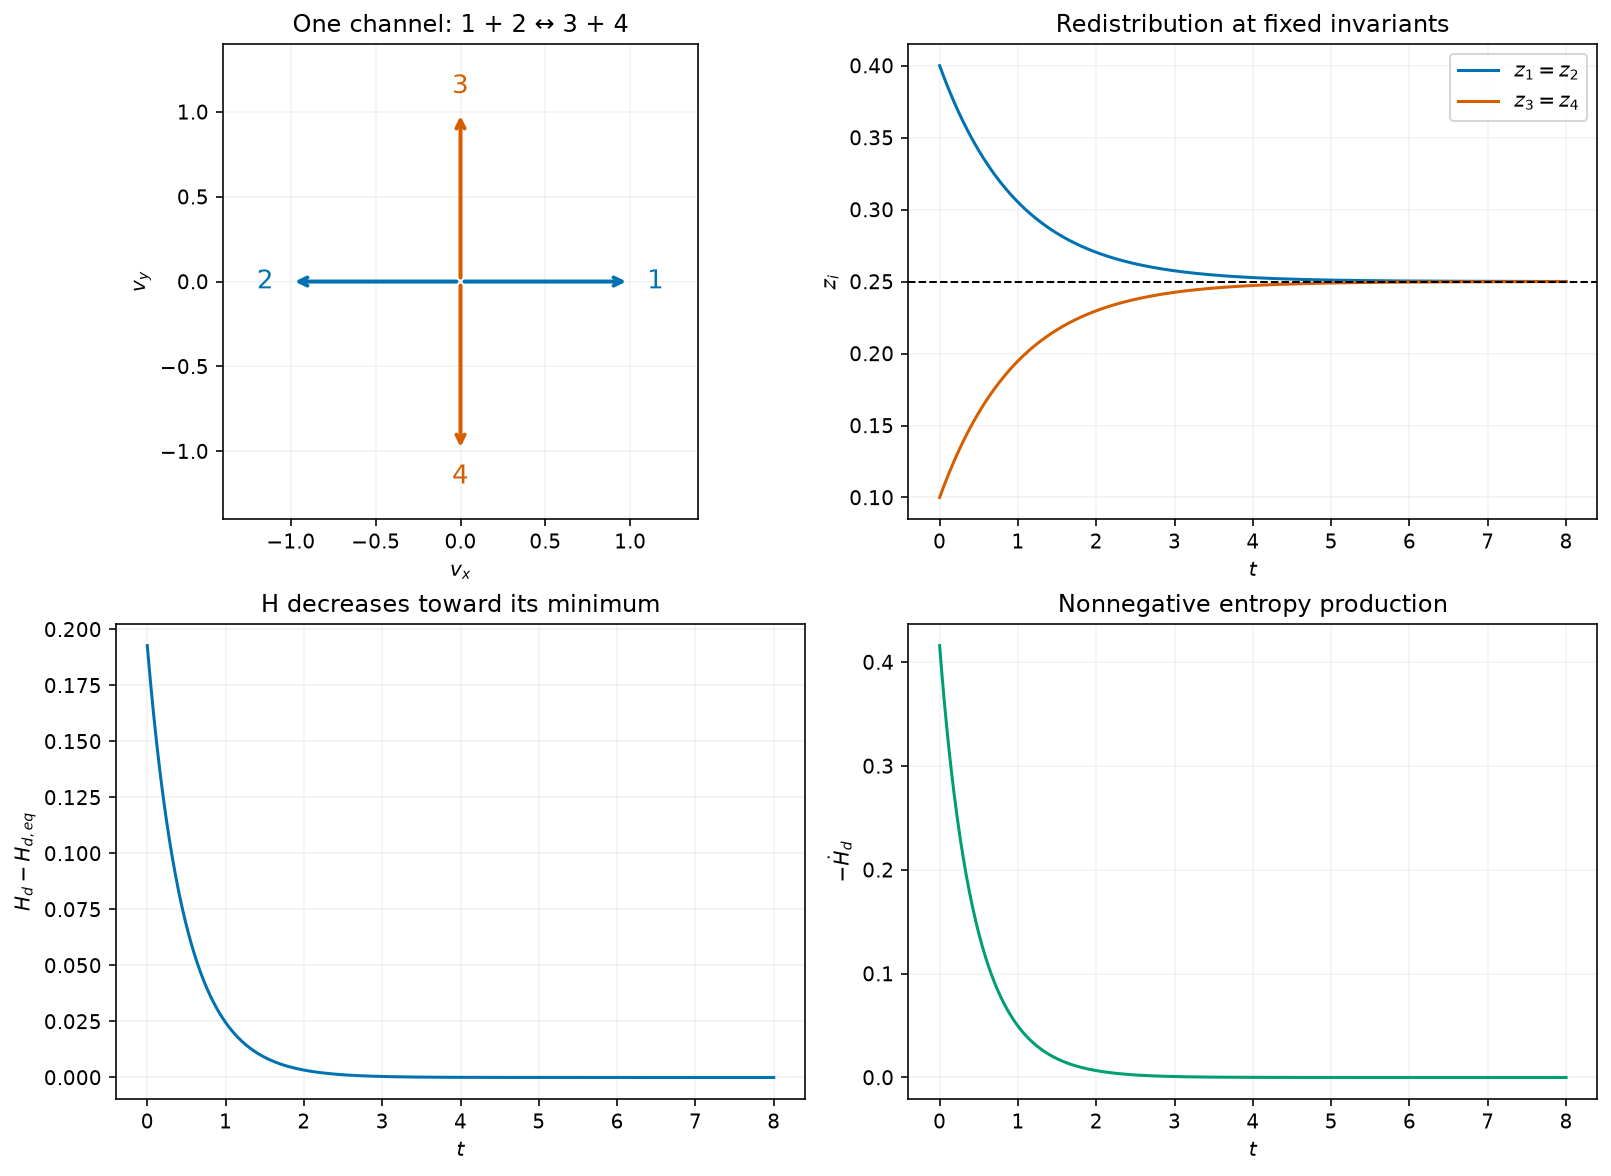

Maximum number / momentum / energy drift: 0.0 0.0 0.0
Maximum H-rate identity error: 1.1102230246251565e-16


In [1]:
import numpy as np
import matplotlib.pyplot as plt

ht_lang = "en"
def ht_text(en, ua):
    return ua if ht_lang == "uk" else en

ht_t = np.linspace(0, 8, 801)
ht_a = .25 + .15*np.exp(-ht_t)
ht_z = np.column_stack([ht_a, ht_a, .5-ht_a, .5-ht_a])
ht_v = np.array([[1.,0.],[-1.,0.],[0.,1.],[0.,-1.]])
ht_q = ht_z[:,0]*ht_z[:,1] - ht_z[:,2]*ht_z[:,3]
ht_dz = np.column_stack([-ht_q,-ht_q,ht_q,ht_q])
ht_H = np.sum(ht_z*np.log(ht_z),axis=1)
ht_H_eq = -np.log(4.)
ht_prod = ht_q*np.log((ht_z[:,0]*ht_z[:,1])/(ht_z[:,2]*ht_z[:,3]))
ht_Hdot = np.sum((1+np.log(ht_z))*ht_dz,axis=1)
ht_number = ht_z.sum(axis=1)
ht_momentum = ht_z@ht_v
ht_energy = ht_z@(np.sum(ht_v**2,axis=1)/2)
assert np.all(ht_z>0)
assert np.allclose(ht_number,1.,atol=1e-14)
assert np.max(np.abs(ht_momentum))<1e-14
assert np.allclose(ht_energy,.5,atol=1e-14)
assert np.max(np.diff(ht_H))<=1e-14
assert np.allclose(ht_Hdot,-ht_prod,atol=1e-14)

ht_fig, ht_axes = plt.subplots(2,2,figsize=(11,8),layout="constrained")
ht_ax=ht_axes[0,0]
for ht_i,ht_vec in enumerate(ht_v):
    ht_color="#0072B2" if ht_i<2 else "#D55E00"
    ht_ax.annotate("",xy=ht_vec,xytext=(0,0),arrowprops=dict(arrowstyle="->",lw=2,color=ht_color))
    ht_ax.text(*(1.15*ht_vec),str(ht_i+1),ha="center",va="center",fontsize=13,color=ht_color)
ht_ax.set(xlim=(-1.4,1.4),ylim=(-1.4,1.4),xlabel="$v_x$",ylabel="$v_y$",
          title=ht_text("One channel: 1 + 2 ↔ 3 + 4","Один канал: 1 + 2 ↔ 3 + 4"))
ht_ax.set_aspect("equal"); ht_ax.grid(alpha=.15)
ht_axes[0,1].plot(ht_t,ht_a,label="$z_1=z_2$",color="#0072B2")
ht_axes[0,1].plot(ht_t,.5-ht_a,label="$z_3=z_4$",color="#D55E00")
ht_axes[0,1].axhline(.25,color="black",ls="--",lw=1)
ht_axes[0,1].set(xlabel="$t$",ylabel="$z_i$",title=ht_text("Redistribution at fixed invariants","Перерозподіл за сталих інваріантів"))
ht_axes[0,1].legend()
ht_axes[1,0].plot(ht_t,ht_H-ht_H_eq,color="#0072B2")
ht_axes[1,0].set(xlabel="$t$",ylabel="$H_d-H_{d,eq}$",title=ht_text("H decreases toward its minimum","H спадає до мінімуму"))
ht_axes[1,1].plot(ht_t,ht_prod,color="#009E73")
ht_axes[1,1].set(xlabel="$t$",ylabel=r"$-\dot H_d$",title=ht_text("Nonnegative entropy production","Невід'ємне виробництво ентропії"))
for ht_ax in ht_axes.flat: ht_ax.grid(alpha=.15)
plt.show()
print(ht_text("Maximum number / momentum / energy drift:","Максимальний дрейф числа / імпульсу / енергії:"),
      np.max(abs(ht_number-1)),np.max(abs(ht_momentum)),np.max(abs(ht_energy-.5)))
print(ht_text("Maximum H-rate identity error:","Максимальна похибка тотожності для швидкості H:"),np.max(abs(ht_Hdot+ht_prod)))


## 10. An illustrative relaxation toward a Gaussian

To visualize a changing distribution without implementing the full collision integral, use the homogeneous **BGK relaxation model**, $\partial_t f=\nu(f_M-f)$, with $f_M$ chosen to have the same conserved moments. In the homogeneous problem these moments are constant, hence

$$f(t)=f_M+e^{-\nu t}(f_0-f_M).$$

It is a positive convex combination. Moment matching and the invariant form of $\ln f_M$ imply the model's own entropy inequality:

$$\dot h=-\nu\int(f-f_M)\ln(f/f_M)\,d^3p\le0.$$

This shares the sign structure of the H-theorem, but it is not the full Boltzmann dynamics. In particular, its relaxation rate is prescribed rather than calculated from a scattering kernel.

The plot uses a normalized one-component velocity marginal $g(v)$ in dimensionless units, with an initially bimodal distribution:

$$g_0(v)=\tfrac12\mathcal N(v;-u_b,s_0^2)+\tfrac12\mathcal N(v;u_b,s_0^2),
\quad u_b=2,\ s_0=0.6,\quad
M(v)=\mathcal N(v;0,u_b^2+s_0^2).$$

This is a marginal BGK illustration, not a gas of identical particles with only one-dimensional elastic collisions (those merely exchange velocities). The marginal's mass, mean velocity, and second moment are matched. Its excess H is $\int g\ln(g/M)dv$, an information measure for this marginal—not automatically the full three-dimensional gas entropy. The finite integration interval and grid are explicitly checked.


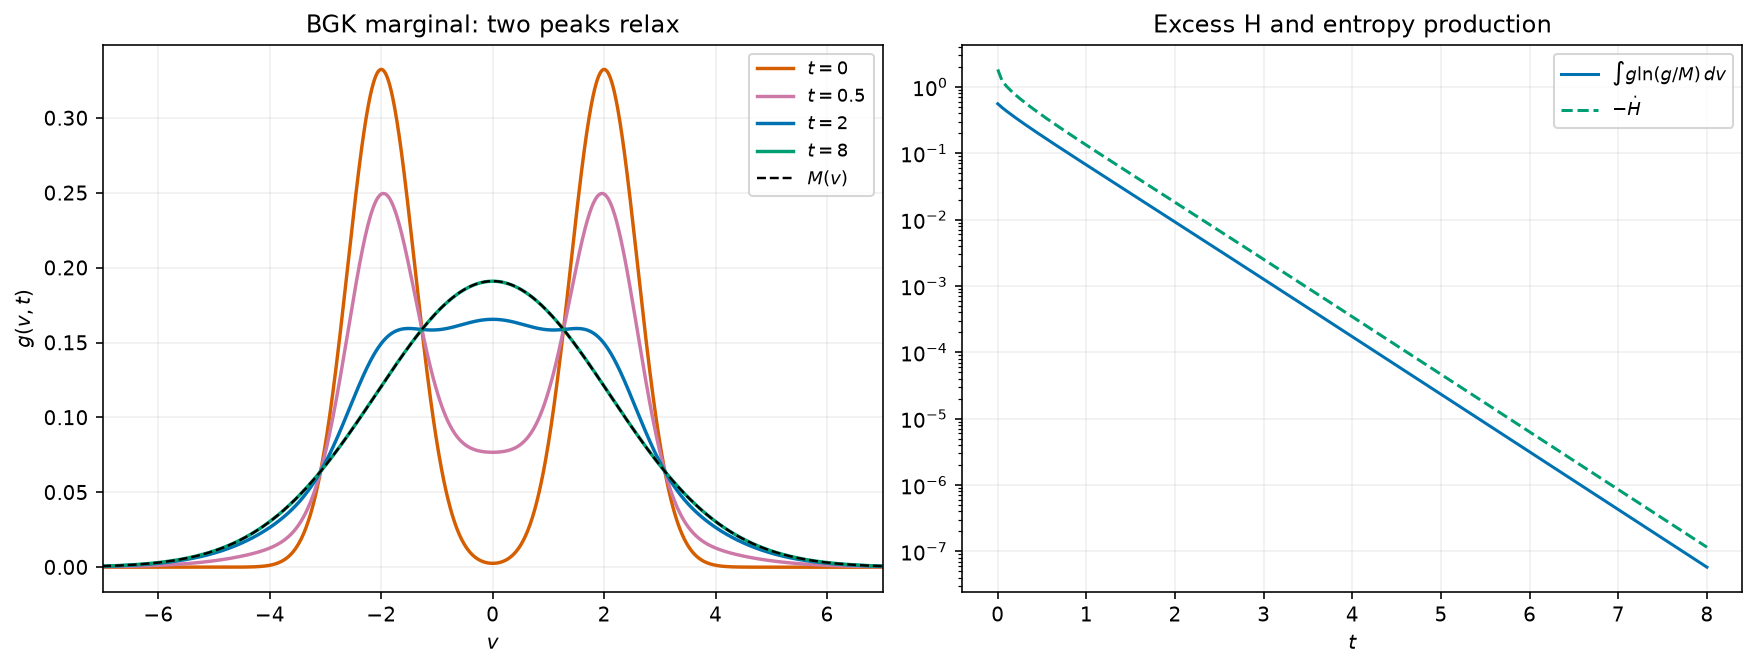

Maximum moment errors (mass, mean, second moment): [1.82076576e-14 2.22044605e-16 4.82014428e-12]
Grid/domain refinement: maximum excess-H difference: 6.716849298982197e-15


In [2]:
def ht_gaussian(v,mean,variance):
    return np.exp(-(v-mean)**2/(2*variance))/np.sqrt(2*np.pi*variance)

def ht_integral(y,x,axis=-1):
    # Explicit trapezoidal quadrature, compatible with older NumPy versions.
    y=np.moveaxis(np.asarray(y),axis,-1)
    return np.sum((y[...,1:]+y[...,:-1])*np.diff(x)/2,axis=-1)

def ht_bgk_grid(limit,points,times):
    v=np.linspace(-limit,limit,points)
    g0=.5*ht_gaussian(v,-2,.6**2)+.5*ht_gaussian(v,2,.6**2)
    M=ht_gaussian(v,0,4+.6**2)
    weight=np.exp(-times[:,None])
    g=weight*g0[None,:]+(1-weight)*M[None,:]
    assert np.all(g>0) and np.all(M>0)
    moments=np.column_stack([ht_integral(g,v),ht_integral(g*v,v),ht_integral(g*v*v,v)])
    excess=ht_integral(g*np.log(g/M),v)
    prod=ht_integral((g-M)*np.log(g/M),v)
    H=ht_integral(g*np.log(g),v)
    HM=ht_integral(M*np.log(M),v)
    return v,g0,M,g,moments,excess,prod,H-HM

ht_times=np.linspace(0,8,161)
ht_result=ht_bgk_grid(16,3201,ht_times)
ht_vgrid,ht_g0,ht_M,ht_g,ht_mom,ht_excess,ht_bgk_prod,ht_deltaH=ht_result
ht_target=np.array([1.,0.,4.36])
assert np.max(abs(ht_mom-ht_target))<1e-10
assert np.min(ht_excess)>-1e-12
assert np.max(np.diff(ht_excess))<1e-12
assert np.min(ht_bgk_prod)>-1e-12
assert np.max(abs(ht_excess-ht_deltaH))<1e-10
ht_fine=ht_bgk_grid(18,7201,ht_times)
assert np.max(abs(ht_excess-ht_fine[5]))<1e-9

ht_fig,ht_axes=plt.subplots(1,2,figsize=(12,4.5),layout="constrained")
for ht_time,ht_color in zip([0,.5,2,8],["#D55E00","#CC79A7","#0072B2","#009E73"]):
    ht_index=np.argmin(abs(ht_times-ht_time))
    ht_axes[0].plot(ht_vgrid,ht_g[ht_index],label=fr"$t={ht_time:g}$",color=ht_color,lw=1.7)
ht_axes[0].plot(ht_vgrid,ht_M,"k--",lw=1.2,label="$M(v)$")
ht_axes[0].set(xlim=(-7,7),xlabel="$v$",ylabel="$g(v,t)$",
    title=ht_text("BGK marginal: two peaks relax","Маргінальний розподіл БГК: релаксація"))
ht_axes[0].legend(fontsize=9)
ht_axes[1].semilogy(ht_times,ht_excess,color="#0072B2",label=r"$\int g\ln(g/M)\,dv$")
ht_axes[1].semilogy(ht_times,ht_bgk_prod,color="#009E73",ls="--",label=r"$-\dot H$")
ht_axes[1].set(xlabel="$t$",title=ht_text("Excess H and entropy production","Надлишок H та виробництво ентропії"))
ht_axes[1].legend(fontsize=9)
for ht_ax in ht_axes: ht_ax.grid(alpha=.2)
plt.show()
print(ht_text("Maximum moment errors (mass, mean, second moment):","Максимальні похибки моментів (маса, середнє, другий момент):"),np.max(abs(ht_mom-ht_target),axis=0))
print(ht_text("Grid/domain refinement: maximum excess-H difference:","Уточнення сітки й області: максимальна різниця надлишку H:"),np.max(abs(ht_excess-ht_fine[5])))


## 11. Questions for discussion and independent work

1. Reproduce both symmetrizations in the weak form. Explain the factor $1/4$ and why the same factor does not appear in the single-channel model.
2. Verify conservation of momentum and energy for the hard-sphere collision rule. Which part of the H-theorem would fail for an arbitrary collision rule?
3. Derive the normalization and three moments of $f_M$. Show why a general local Maxwellian does not make the streaming term vanish.
4. Prove the relative-entropy identity at fixed number, momentum, and energy. State exactly where the fixed constraints enter.
5. Change the discrete initial populations while keeping them positive. For nonsymmetric initial data, use $\dot{\mathbf z}=(-q,-q,q,q)$ and find equilibrium under the new invariants; do not reuse the special symmetric analytic solution.
6. Change the beam separation and width in the BGK example, updating the target variance consistently. Compare H-decay while checking conservation and quadrature accuracy. Why is this not a measurement of the true Boltzmann collision rate?
7. Describe what happens to incoming correlations under microscopic time reversal. Distinguish kinetic entropy from fine-grained Gibbs entropy.
8. In a steady open system with positive entropy production, determine the sign of the net entropy exchange. Explain why this permits—but does not by itself predict—a coherent laser field or a spatial pattern.

**Deliverable:** one checked derivation, one annotated figure with numerical error estimates, and a paragraph identifying the assumptions and the limits of your conclusion.


## Reading and source correspondence

The main source is the author's Ukrainian course *Nonequilibrium Thermodynamics and Statistical Physics*: `stphysneq_ua.tex`, including `sec_gaskinetic_ua.tex`. This notebook follows its microscopic-density discussion, its treatment of incoming pair momenta, and the subsection on collision-integral properties and the H-theorem. The added continuum sections develop the transport balances and illustrate their closure with the BGK model.

| Source labels | Notebook treatment |
|---|---|
| `micro1`, `normmicro1`, `g2`, `f2_factor` | Microscopic density, normalization, correlations, kinetic closure |
| `subsec_kineqboltzmech`, `kinb` | Elastic collisions and gain–loss equation |
| `phi`, `phi0`, `pp`, `boltzmanint` | Fully normalized weak form and collision invariants |
| `loceq_mxwl`, `boltz0`, `s1_hteorem` | Maxwellian, explicit sign proof, and entropy balance |

**Editorial clarifications in this adaptation.** All collision prefactors are included in $B$ before symmetrization. The product $(Y-X)\ln(X/Y)$ is nonpositive, not nonnegative. The momentum Maxwellian has $2mk_BT$ in its exponent denominator. Collision invariants include an independent linear momentum term. Local entropy change includes transport; the collision contribution alone is not the complete local time derivative in an inhomogeneous gas. The original TeX files have not been edited.

Further reading:

- David Tong, [*Lectures on Kinetic Theory*, Chapter 2](https://www.damtp.cam.ac.uk/user/tong/kintheory/kintheory.pdf), especially the Boltzmann equation and H-theorem sections.
- P. L. Bhatnagar, E. P. Gross, M. Krook, [“A Model for Collision Processes in Gases. I”](https://doi.org/10.1103/PhysRev.94.511), *Physical Review* **94**, 511–525 (1954), for the relaxation-model idea used in the computational illustration.

All figures in this notebook are generated by its own code. The kinetic proof and the two illustrative models are separate: neither numerical figure is presented as a solution of the full Boltzmann collision integral.
